# FSA Study Area and Weather Station Coverage — Toronto CMA

This notebook downloads official 2021 Statistics Canada cartographic boundaries
through the REST API and creates a presentation-ready study-area map.

Main output:
- Toronto CMA as geographic context
- Six study FSAs highlighted
- Two weather stations
- Station-to-FSA assignment colors

Optional output:
- Same Toronto CMA map with a small Ontario inset.


In [ ]:
# Run only if needed:
# %pip install geopandas requests matplotlib shapely pyproj


In [1]:
from pathlib import Path
import json
import requests
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------------
# Output directory
# ---------------------------------------------------------------------------
OUTPUT_DIR = Path("map_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Study configuration
# ---------------------------------------------------------------------------
STUDY_FSAS = ["L4T", "M5R", "M5S", "M6G", "M9R", "M9W"]

STATIONS = pd.DataFrame(
    [
        {
            "station": "Toronto City",
            "climate_id": "6158355",
            "latitude": 43.6667,
            "longitude": -79.4000,
        },
        {
            "station": "Toronto INTL A",
            "climate_id": "6158731",
            "latitude": 43.6767,
            "longitude": -79.6306,
        },
    ]
)

FSA_TO_STATION = {
    "M5S": "Toronto City",
    "M5R": "Toronto City",
    "M6G": "Toronto City",
    "L4T": "Toronto INTL A",
    "M9W": "Toronto INTL A",
    "M9R": "Toronto INTL A",
}

COVERAGE_COLORS = {
    "Toronto City": "#4C78A8",
    "Toronto INTL A": "#F28E2B",
}

# ---------------------------------------------------------------------------
# Statistics Canada REST endpoints
# ---------------------------------------------------------------------------
BASE_URL = (
    "https://geo.statcan.gc.ca/geo_wa/rest/services/"
    "2021/Cartographic_boundary_files/MapServer"
)

FSA_LAYER_URL = f"{BASE_URL}/14/query"
CMA_LAYER_URL = f"{BASE_URL}/6/query"
PROVINCE_LAYER_URL = f"{BASE_URL}/0/query"


def download_geojson(url: str, params: dict, output_path: Path) -> dict:
    """Download a GeoJSON response from Statistics Canada and save it locally."""
    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()

    geojson = response.json()

    if "features" not in geojson or len(geojson["features"]) == 0:
        raise RuntimeError(
            f"No geometries returned by Statistics Canada.\n"
            f"Request URL: {response.url}"
        )

    output_path.write_text(
        json.dumps(geojson),
        encoding="utf-8",
    )

    print(f"Downloaded {len(geojson['features'])} feature(s)")
    print(f"Saved: {output_path.resolve()}")

    return geojson


def load_or_download_fsa() -> gpd.GeoDataFrame:
    """Retrieve only the six study FSAs."""
    output_path = OUTPUT_DIR / "study_fsas_statcan_2021.geojson"

    if not output_path.exists():
        where_clause = "CFSAUID IN ({})".format(
            ",".join(f"'{fsa}'" for fsa in STUDY_FSAS)
        )

        params = {
            "where": where_clause,
            "outFields": "CFSAUID,PRUID,PRNAME,LANDAREA",
            "returnGeometry": "true",
            "outSR": "4326",
            "f": "geojson",
        }

        download_geojson(
            FSA_LAYER_URL,
            params,
            output_path,
        )

    fsas = gpd.read_file(output_path)
    fsas["CFSAUID"] = fsas["CFSAUID"].astype(str)

    fsas = fsas.loc[
        fsas["CFSAUID"].isin(STUDY_FSAS)
    ].copy()

    missing_fsas = sorted(
        set(STUDY_FSAS) - set(fsas["CFSAUID"])
    )

    if missing_fsas:
        raise RuntimeError(
            f"Missing FSA geometries: {missing_fsas}"
        )

    fsas["assigned_station"] = (
        fsas["CFSAUID"].map(FSA_TO_STATION)
    )

    return fsas


def load_or_download_toronto_cma() -> gpd.GeoDataFrame:
    """Retrieve the Toronto Census Metropolitan Area boundary."""
    output_path = OUTPUT_DIR / "toronto_cma_statcan_2021.geojson"

    if not output_path.exists():
        # Toronto CMAUID = 535.
        params = {
            "where": "CMAUID = '535'",
            "outFields": "CMAUID,CMANAME,CMATYPE",
            "returnGeometry": "true",
            "outSR": "4326",
            "f": "geojson",
        }

        download_geojson(
            CMA_LAYER_URL,
            params,
            output_path,
        )

    return gpd.read_file(output_path)


def load_or_download_ontario() -> gpd.GeoDataFrame:
    """Retrieve the Ontario provincial boundary for optional geographic context."""
    output_path = OUTPUT_DIR / "ontario_statcan_2021.geojson"

    if not output_path.exists():
        # Ontario PRUID = 35.
        params = {
            "where": "PRUID = '35'",
            "outFields": "PRUID,PRNAME",
            "returnGeometry": "true",
            "outSR": "4326",
            "f": "geojson",
        }

        download_geojson(
            PROVINCE_LAYER_URL,
            params,
            output_path,
        )

    return gpd.read_file(output_path)


def build_station_geodataframe() -> gpd.GeoDataFrame:
    """Create a GeoDataFrame for the two weather stations."""
    return gpd.GeoDataFrame(
        STATIONS.copy(),
        geometry=gpd.points_from_xy(
            STATIONS["longitude"],
            STATIONS["latitude"],
        ),
        crs="EPSG:4326",
    )


def plot_study_area_with_cma(
    fsas: gpd.GeoDataFrame,
    toronto_cma: gpd.GeoDataFrame,
    stations_gdf: gpd.GeoDataFrame,
    output_path: Path,
    show_assignment_lines: bool = True,
) -> None:
    """Create a presentation-ready study-area map within the Toronto CMA."""
    # Statistics Canada Lambert projection.
    fsas_plot = fsas.to_crs("EPSG:3347")
    cma_plot = toronto_cma.to_crs("EPSG:3347")
    stations_plot = stations_gdf.to_crs("EPSG:3347")

    fig, ax = plt.subplots(figsize=(12, 10))

    # Toronto CMA context.
    cma_plot.plot(
        ax=ax,
        facecolor="#F3F3F3",
        edgecolor="#777777",
        linewidth=1.2,
        alpha=1.0,
        zorder=0,
    )

    # Study FSAs by assigned station.
    for station_name, color in COVERAGE_COLORS.items():
        subset = fsas_plot.loc[
            fsas_plot["assigned_station"] == station_name
        ]

        subset.plot(
            ax=ax,
            facecolor=color,
            edgecolor="white",
            linewidth=1.8,
            alpha=0.65,
            zorder=3,
        )

    # Re-draw FSA borders for clarity.
    fsas_plot.boundary.plot(
        ax=ax,
        color="#555555",
        linewidth=1.0,
        alpha=0.9,
        zorder=4,
    )

    # FSA labels.
    for _, row in fsas_plot.iterrows():
        point = row.geometry.representative_point()

        ax.text(
            point.x,
            point.y,
            row["CFSAUID"],
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="#222222",
            bbox={
                "boxstyle": "round,pad=0.22",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.85,
            },
            zorder=6,
        )

    # Weather stations.
    for _, station in stations_plot.iterrows():
        color = COVERAGE_COLORS[station["station"]]

        ax.scatter(
            station.geometry.x,
            station.geometry.y,
            s=320,
            marker="*",
            color=color,
            edgecolor="black",
            linewidth=1.2,
            zorder=8,
        )

        ax.annotate(
            (
                f'{station["station"]}\n'
                f'Climate ID {station["climate_id"]}'
            ),
            xy=(
                station.geometry.x,
                station.geometry.y,
            ),
            xytext=(12, 12),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
            bbox={
                "boxstyle": "round,pad=0.3",
                "facecolor": "white",
                "edgecolor": "#BBBBBB",
                "alpha": 0.94,
            },
            zorder=9,
        )

    # Optional station-to-FSA lines.
    if show_assignment_lines:
        station_lookup = {
            row["station"]: row.geometry
            for _, row in stations_plot.iterrows()
        }

        for _, row in fsas_plot.iterrows():
            fsa_point = row.geometry.representative_point()
            station_point = station_lookup[
                row["assigned_station"]
            ]

            ax.plot(
                [station_point.x, fsa_point.x],
                [station_point.y, fsa_point.y],
                color=COVERAGE_COLORS[
                    row["assigned_station"]
                ],
                linewidth=0.7,
                linestyle="--",
                alpha=0.30,
                zorder=2,
            )

    # Legend.
    legend_items = [
        Line2D(
            [0], [0],
            marker="s",
            color="none",
            markerfacecolor=COVERAGE_COLORS["Toronto City"],
            markeredgecolor="none",
            markersize=12,
            alpha=0.65,
            label="FSA coverage — Toronto City",
        ),
        Line2D(
            [0], [0],
            marker="s",
            color="none",
            markerfacecolor=COVERAGE_COLORS["Toronto INTL A"],
            markeredgecolor="none",
            markersize=12,
            alpha=0.65,
            label="FSA coverage — Toronto INTL A",
        ),
        Line2D(
            [0], [0],
            marker="*",
            color="black",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=14,
            linestyle="None",
            label="Weather station",
        ),
    ]

    ax.legend(
        handles=legend_items,
        loc="upper left",
        frameon=True,
        framealpha=0.95,
        title="Study-area assignment",
    )

    # Use the complete Toronto CMA for map extent.
    minx, miny, maxx, maxy = cma_plot.total_bounds

    x_padding = (maxx - minx) * 0.04
    y_padding = (maxy - miny) * 0.04

    ax.set_xlim(
        minx - x_padding,
        maxx + x_padding,
    )

    ax.set_ylim(
        miny - y_padding,
        maxy + y_padding,
    )

    ax.set_title(
        "Ontario Electricity Demand Study Area within the Toronto CMA",
        fontsize=15,
        fontweight="semibold",
        pad=14,
    )

    ax.set_axis_off()

    ax.text(
        0.01,
        0.01,
        (
            "Boundaries: Statistics Canada, "
            "2021 Census Cartographic Boundary Files."
        ),
        transform=ax.transAxes,
        fontsize=8,
        color="#555555",
        ha="left",
        va="bottom",
    )

    fig.tight_layout()

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()

    print(f"Saved map: {output_path.resolve()}")


def plot_study_area_with_ontario_inset(
    fsas: gpd.GeoDataFrame,
    toronto_cma: gpd.GeoDataFrame,
    ontario: gpd.GeoDataFrame,
    stations_gdf: gpd.GeoDataFrame,
    output_path: Path,
) -> None:
    """
    Create the Toronto CMA study-area map plus a small Ontario inset
    showing where the Toronto CMA is located within the province.
    """
    fsas_plot = fsas.to_crs("EPSG:3347")
    cma_plot = toronto_cma.to_crs("EPSG:3347")
    ontario_plot = ontario.to_crs("EPSG:3347")
    stations_plot = stations_gdf.to_crs("EPSG:3347")

    fig, ax = plt.subplots(figsize=(13, 10))

    # Main Toronto CMA layer.
    cma_plot.plot(
        ax=ax,
        facecolor="#F3F3F3",
        edgecolor="#777777",
        linewidth=1.2,
        zorder=0,
    )

    for station_name, color in COVERAGE_COLORS.items():
        subset = fsas_plot.loc[
            fsas_plot["assigned_station"] == station_name
        ]

        subset.plot(
            ax=ax,
            facecolor=color,
            edgecolor="white",
            linewidth=1.8,
            alpha=0.68,
            zorder=3,
        )

    fsas_plot.boundary.plot(
        ax=ax,
        color="#555555",
        linewidth=1.0,
        zorder=4,
    )

    for _, row in fsas_plot.iterrows():
        p = row.geometry.representative_point()

        ax.text(
            p.x,
            p.y,
            row["CFSAUID"],
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            bbox={
                "boxstyle": "round,pad=0.22",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.85,
            },
            zorder=6,
        )

    for _, station in stations_plot.iterrows():
        color = COVERAGE_COLORS[station["station"]]

        ax.scatter(
            station.geometry.x,
            station.geometry.y,
            s=320,
            marker="*",
            color=color,
            edgecolor="black",
            linewidth=1.2,
            zorder=8,
        )

        ax.annotate(
            (
                f'{station["station"]}\n'
                f'Climate ID {station["climate_id"]}'
            ),
            xy=(station.geometry.x, station.geometry.y),
            xytext=(12, 12),
            textcoords="offset points",
            fontsize=9,
            fontweight="bold",
            bbox={
                "boxstyle": "round,pad=0.3",
                "facecolor": "white",
                "edgecolor": "#BBBBBB",
                "alpha": 0.94,
            },
            zorder=9,
        )

    # Main map extent.
    minx, miny, maxx, maxy = cma_plot.total_bounds
    x_padding = (maxx - minx) * 0.04
    y_padding = (maxy - miny) * 0.04

    ax.set_xlim(minx - x_padding, maxx + x_padding)
    ax.set_ylim(miny - y_padding, maxy + y_padding)

    ax.set_title(
        "Ontario Electricity Demand Study Area within the Toronto CMA",
        fontsize=15,
        fontweight="semibold",
        pad=14,
    )
    ax.set_axis_off()

    # Ontario inset.
    inset_ax = fig.add_axes([0.67, 0.62, 0.27, 0.27])

    ontario_plot.plot(
        ax=inset_ax,
        facecolor="#EFEFEF",
        edgecolor="#777777",
        linewidth=0.7,
    )

    cma_plot.plot(
        ax=inset_ax,
        facecolor="#C44E52",
        edgecolor="#C44E52",
        linewidth=0.8,
        alpha=0.85,
    )

    inset_ax.set_title(
        "Toronto CMA within Ontario",
        fontsize=9,
    )
    inset_ax.set_axis_off()

    # Legend.
    legend_items = [
        Line2D(
            [0], [0],
            marker="s",
            color="none",
            markerfacecolor=COVERAGE_COLORS["Toronto City"],
            markersize=11,
            label="FSA coverage — Toronto City",
        ),
        Line2D(
            [0], [0],
            marker="s",
            color="none",
            markerfacecolor=COVERAGE_COLORS["Toronto INTL A"],
            markersize=11,
            label="FSA coverage — Toronto INTL A",
        ),
        Line2D(
            [0], [0],
            marker="*",
            color="black",
            markerfacecolor="white",
            markersize=13,
            linestyle="None",
            label="Weather station",
        ),
    ]

    ax.legend(
        handles=legend_items,
        loc="upper left",
        frameon=True,
        framealpha=0.95,
        title="Study-area assignment",
    )

    ax.text(
        0.01,
        0.01,
        (
            "Boundaries: Statistics Canada, "
            "2021 Census Cartographic Boundary Files."
        ),
        transform=ax.transAxes,
        fontsize=8,
        color="#555555",
        ha="left",
        va="bottom",
    )

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white",
    )

    plt.show()

    print(f"Saved map with inset: {output_path.resolve()}")


## Generate the main Toronto CMA map

The first execution downloads the required GeoJSON files into `map_outputs/`.
Later executions reuse the local files and do not call the API again.


Downloaded 6 feature(s)
Saved: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\notebooks\maps\map_outputs\study_fsas_statcan_2021.geojson
Downloaded 1 feature(s)
Saved: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\notebooks\maps\map_outputs\toronto_cma_statcan_2021.geojson


,CFSAUID,assigned_station,LANDAREA
0,L4T,Toronto INTL A,33.7566
1,M5R,Toronto City,2.8276
2,M5S,Toronto City,1.8915
3,M6G,Toronto City,3.8615
4,M9R,Toronto INTL A,6.5681
5,M9W,Toronto INTL A,27.3161


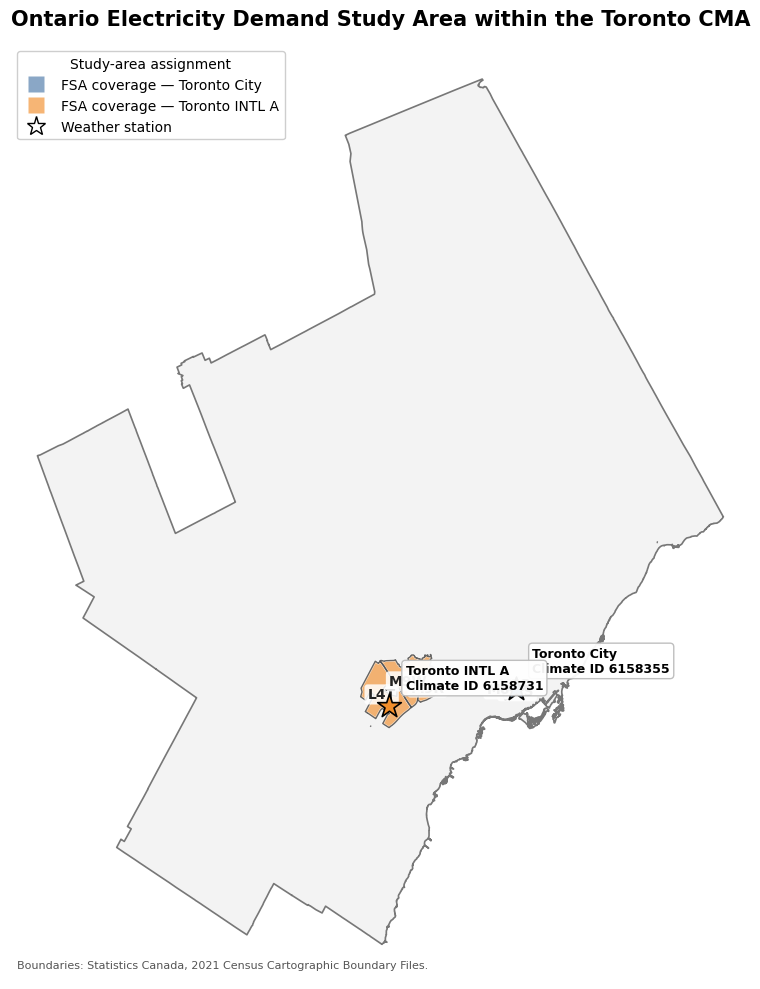

Saved map: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\notebooks\maps\map_outputs\FSA_weather_station_coverage_toronto_CMA.png


In [2]:
# ---------------------------------------------------------------------------
# Download/load geographic data
# ---------------------------------------------------------------------------
fsas = load_or_download_fsa()
toronto_cma = load_or_download_toronto_cma()
stations_gdf = build_station_geodataframe()

display(
    fsas[
        ["CFSAUID", "assigned_station", "LANDAREA"]
    ].sort_values("CFSAUID")
)

# ---------------------------------------------------------------------------
# Main Toronto CMA map
# ---------------------------------------------------------------------------
plot_study_area_with_cma(
    fsas=fsas,
    toronto_cma=toronto_cma,
    stations_gdf=stations_gdf,
    output_path=OUTPUT_DIR / "FSA_weather_station_coverage_toronto_CMA.png",
    show_assignment_lines=True,
)


## Optional — add an Ontario inset

Run this cell only if you want a small locator map showing the Toronto CMA
within Ontario.


In [3]:
# ---------------------------------------------------------------------------
# OPTIONAL: Toronto CMA map with an Ontario inset
# ---------------------------------------------------------------------------
ontario = load_or_download_ontario()

plot_study_area_with_ontario_inset(
    fsas=fsas,
    toronto_cma=toronto_cma,
    ontario=ontario,
    stations_gdf=stations_gdf,
    output_path=OUTPUT_DIR / "FSA_weather_station_coverage_toronto_CMA_with_Ontario_inset.png",
)


HTTPError: 500 Server Error: Internal Server Error for url: https://geo.statcan.gc.ca/geo_wa/rest/services/2021/Cartographic_boundary_files/MapServer/0/query?where=PRUID+%3D+%2735%27&outFields=PRUID%2CPRNAME&returnGeometry=true&outSR=4326&f=geojson